# MetroPT-3 Dataset: Exploratory Data Analysis
The MetroPT-3 dataset is a real-world predictive maintenance dataset collected from an Air Production Unit (APU) on an urban metro train. It contains continuous sensor readings (analog, digital, and GPS) annotated with the ground truth of three catastrophic failures extracted from maintenance reports.

## Dataset overview (from the DSAA 2021 paper)
- **Domain**: Predictive maintenance for urban railway transport (Air Production Unit)
- **Sensors**: 15 process variables (7 analog + 8 digital).
- **Classes**: Unlabeled in the raw data.
- **Sources**: Real data collected from an operating train.
- **Sampling**: 10-second intervals (downsampled from the 1 Hz frequency mentioned in the paper).
- **Labeling**: 4 major APU air leak failures provided externally via the dataset's Data Card (maintenance reports).
- **Time span**: 1/02/2020 to 1/09/2020.

## 1. Setup and data loading

In [1]:
import os
import ot 
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.preprocessing import StandardScaler

from scipy.signal import find_peaks
from scipy.stats import gaussian_kde

sns.set_theme(style='whitegrid', palette='muted')


In [2]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_FILE = os.path.join(PROJECT_ROOT, 'data', 'metropt3', 'MetroPT3(AirCompressor).csv')

ANALOG_SENSORS = [
    'TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs', 
    'Oil_temperature', 'Motor_current'
]

DIGITAL_SENSORS = [
    'COMP', 'DV_eletric', 'Towers', 'MPG', 'LPS', 
    'Pressure_switch', 'Oil_level', 'Caudal_impulses'
]

# Ground truth anomalies 
FAILURES = {
    1: {'type': 'Air Leak', 'start': '2020-04-18 00:00:00', 'end': '2020-04-18 23:59:00'},
    2: {'type': 'Air Leak', 'start': '2020-05-29 23:30:00', 'end': '2020-05-30 06:00:00'},
    3: {'type': 'Air Leak', 'start': '2020-06-05 10:00:00', 'end': '2020-06-07 14:30:00'}, 
    4: {'type': 'Air Leak', 'start': '2020-07-15 14:30:00', 'end': '2020-07-15 19:00:00'} 
}

In [3]:
print("Loading data...")
df = pd.read_csv(DATA_FILE, index_col=0, parse_dates=['timestamp'])
df.set_index('timestamp', inplace=True)
print(f"Total Samples: {len(df):,}")
print(f"Time Span: {df.index.min()} to {df.index.max()}")
print(f"Available Signals: {df.shape[1]}")
print(f"Memory Usage: {df.memory_usage().sum() / 1024**2:.2f} MB")

Loading data...
Total Samples: 1,516,948
Time Span: 2020-02-01 00:00:00 to 2020-09-01 03:59:50
Available Signals: 15
Memory Usage: 185.17 MB


## 2 Dataset Composition

The raw dataset does not contain an anomaly label column. We will inject a binary `Anomaly` label (1 for air leak, 0 for normal) using the failure intervals provided in the Data Card, and then visualize the class imbalance.

In [4]:
df['Anomaly'] = 0
# Inject the 1s for the anomaly periods
for failure_id, info in FAILURES.items():
    start = pd.to_datetime(info['start'])
    end = pd.to_datetime(info['end'])
    df.loc[start:end, 'Anomaly'] = 1
anomaly_samples = df['Anomaly'].sum()
normal_samples = len(df) - anomaly_samples
print(f"Normal samples:  {normal_samples:,} ({normal_samples/len(df)*100:.2f}%)")
print(f"Anomaly samples: {anomaly_samples:,} ({anomaly_samples/len(df)*100:.2f}%)")

display(df.head())

Normal samples:  1,486,994 (98.03%)
Anomaly samples: 29,954 (1.97%)


,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses,Anomaly
timestamp,,,,,,,,,,,,,,,,
2020-02-01 00:00:00,-0.012,9.358,9.340,-0.024,9.358,53.600,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0
2020-02-01 00:00:10,-0.014,9.348,9.332,-0.022,9.348,53.675,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0
2020-02-01 00:00:19,-0.012,9.338,9.322,-0.022,9.338,53.600,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0
2020-02-01 00:00:29,-0.012,9.328,9.312,-0.022,9.328,53.425,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0
2020-02-01 00:00:39,-0.012,9.318,9.302,-0.022,9.318,53.475,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
TP2,1516948.0,1.367826,3.250930,-0.032,-0.014,-0.012,-0.0100,10.676
TP3,1516948.0,8.984611,0.639095,0.730,8.492,8.960,9.4920,10.302
H1,1516948.0,7.568155,3.333200,-0.036,8.254,8.784,9.3740,10.288
DV_pressure,1516948.0,0.055956,0.382402,-0.032,-0.022,-0.020,-0.0180,9.844
Reservoirs,1516948.0,8.985233,0.638307,0.712,8.494,8.960,9.4920,10.300
Oil_temperature,1516948.0,62.644182,6.516261,15.400,57.775,62.700,67.2500,89.050
Motor_current,1516948.0,2.050171,2.302053,0.020,0.040,0.045,3.8075,9.295
COMP,1516948.0,0.836957,0.369405,0.000,1.000,1.000,1.0000,1.000
DV_eletric,1516948.0,0.160611,0.367172,0.000,0.000,0.000,0.0000,1.000
Towers,1516948.0,0.919848,0.271528,0.000,1.000,1.000,1.0000,1.000


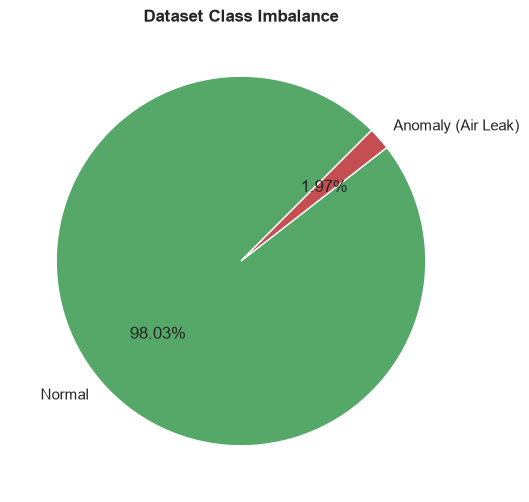

In [6]:
# Plot Class Imbalance
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    [normal_samples, anomaly_samples], 
    labels=['Normal', 'Anomaly (Air Leak)'], 
    colors=['#55A868', '#C44E52'], 
    autopct='%1.2f%%', 
    startangle=45,
    wedgeprops={'edgecolor': 'white'}
)
ax.set_title('Dataset Class Imbalance', fontweight='bold')
plt.show()

## Signal Exploration

- Missing Data
- Downtime Gaps
- Frozen Variables

In [7]:
print("Missing values per sensor in the raw dataset:")
print(df.isnull().sum())
print("\n--- Mean values (Normal vs Anomaly) ---")
display(df.groupby('Anomaly').mean().T.rename(columns={0: 'Normal (Mean)', 1: 'Anomaly (Mean)'}))
print("\n--- Standard Deviation (Normal vs Anomaly) ---")
display(df.groupby('Anomaly').std().T.rename(columns={0: 'Normal (Std)', 1: 'Anomaly (Std)'}))

Missing values per sensor in the raw dataset:
TP2                0
TP3                0
H1                 0
DV_pressure        0
Reservoirs         0
Oil_temperature    0
Motor_current      0
COMP               0
DV_eletric         0
Towers             0
MPG                0
LPS                0
Pressure_switch    0
Oil_level          0
Caudal_impulses    0
Anomaly            0
dtype: int64

--- Mean values (Normal vs Anomaly) ---


Anomaly,Normal (Mean),Anomaly (Mean)
TP2,1.231905,8.115287
TP3,8.998642,8.288059
H1,7.719849,0.037668
DV_pressure,0.019619,1.859813
Reservoirs,8.999247,8.289548
Oil_temperature,62.383231,75.598441
Motor_current,1.980028,5.532224
COMP,0.853727,0.004440
DV_eletric,0.143805,0.994892
Towers,0.928266,0.501970



--- Standard Deviation (Normal vs Anomaly) ---


Anomaly,Normal (Std),Anomaly (Std)
TP2,3.134709,0.982387
TP3,0.633842,0.495399
H1,3.187593,0.627408
DV_pressure,0.277259,0.519533
Reservoirs,0.633052,0.495344
Oil_temperature,6.300423,2.931952
Motor_current,2.270316,0.366727
COMP,0.353380,0.066487
DV_eletric,0.350892,0.071288
Towers,0.258047,0.500004


As mentioned in the datacard the dataset contains no missing values in the recorded rows. However, because the train was not always in operation, there are large gaps in the time series. We will visualize these gaps to understand the system downtime.

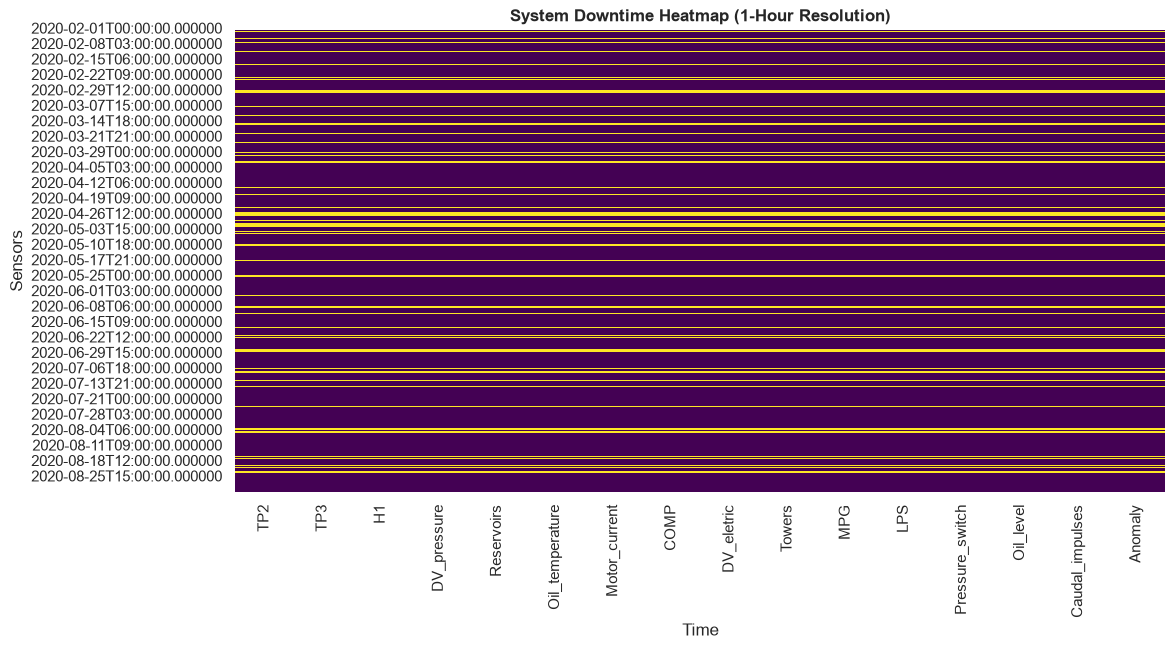

Total monitored hours: 5,116
Completely offline hours: 700 (13.68%)


In [8]:
df_hourly = df.resample('1h').mean()
plt.figure(figsize=(12, 6))
sns.heatmap(df_hourly.isnull(), cbar=False, cmap='viridis')
plt.title("System Downtime Heatmap (1-Hour Resolution)", fontweight='bold')
plt.xlabel("Time")
plt.ylabel("Sensors")
plt.show()
missing_hours = df_hourly.isnull().all(axis=1).sum()
total_hours = len(df_hourly)
print(f"Total monitored hours: {total_hours:,}")
print(f"Completely offline hours: {missing_hours:,} ({missing_hours/total_hours*100:.2f}%)")

## 4. Anomaly Event Signatures 

To understand the physical impact of the failures, we will calculate the duration of the 4 air leaks and plot a zoomed-in snapshot of the critical sensors to observe their behavior right before, during, and after the events.


In [9]:
print("Duration of the 4 Anomaly Events:\n")
duration_stats = []
for failure_id, info in FAILURES.items():
    start_time = pd.to_datetime(info['start'])
    end_time = pd.to_datetime(info['end'])
    duration_hours = (end_time - start_time).total_seconds() / 3600
    
    duration_stats.append({
        'Failure Event': failure_id,
        'Type': info['type'],
        'Component': info['component'] if 'component' in info else 'APU',
        'Duration (Hours)': round(duration_hours, 1)
    })
display(pd.DataFrame(duration_stats).set_index('Failure Event'))

Duration of the 4 Anomaly Events:



,Type,Component,Duration (Hours)
Failure Event,,,
1,Air Leak,APU,24.0
2,Air Leak,APU,6.5
3,Air Leak,APU,52.5
4,Air Leak,APU,4.5


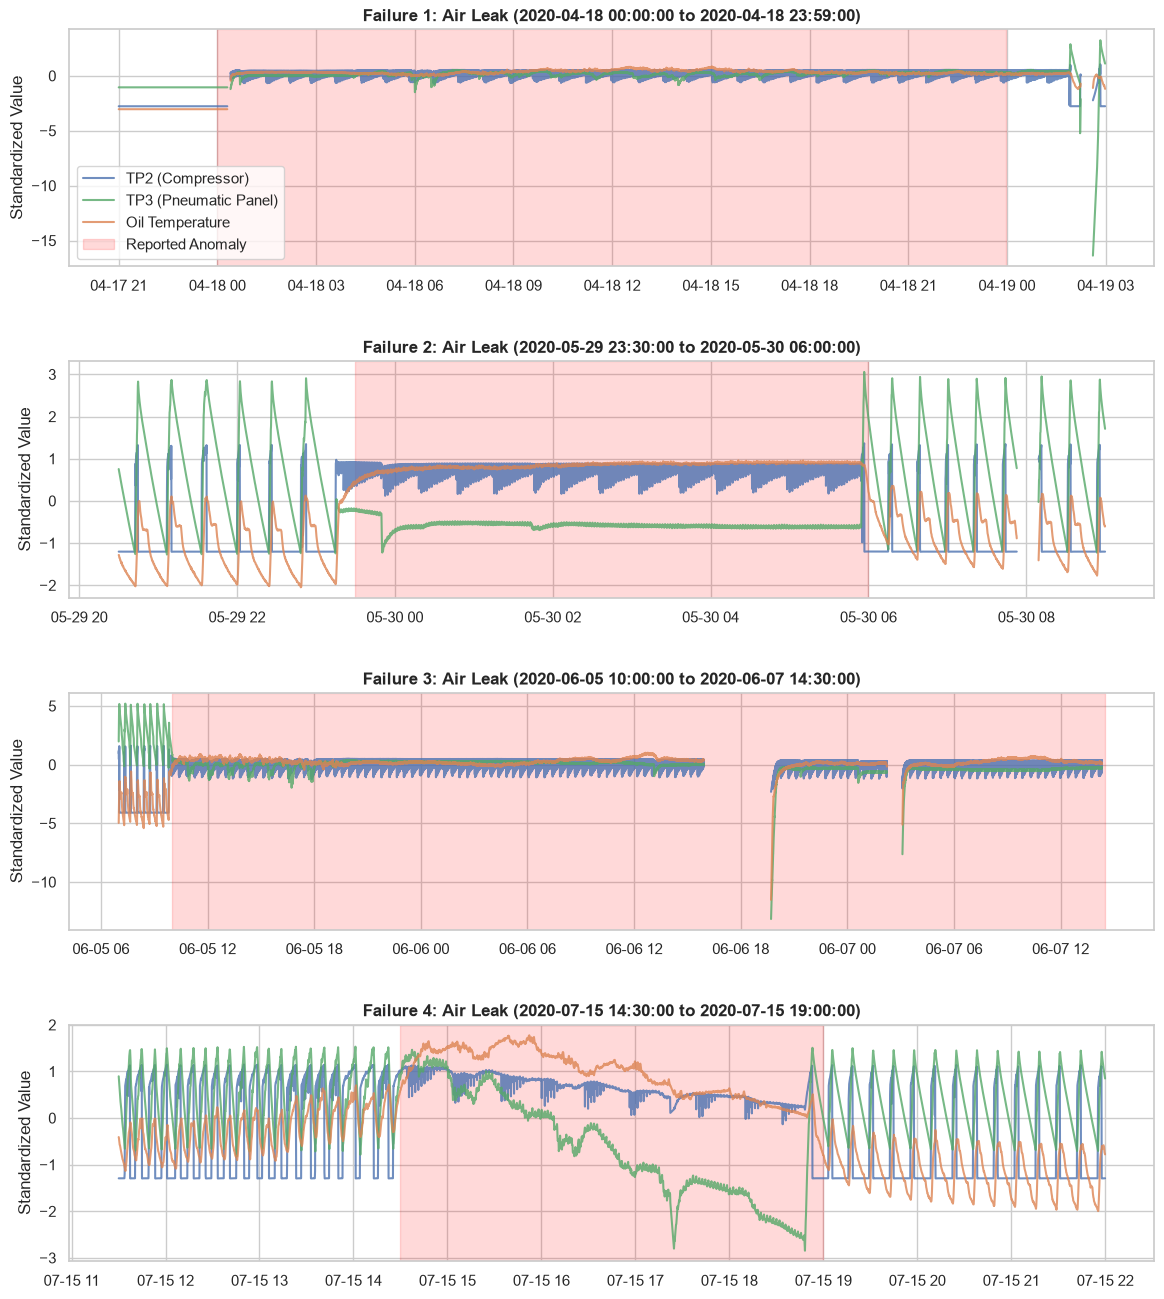

In [10]:
fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=False)
fig.subplots_adjust(hspace=0.4)
for idx, (failure_id, info) in enumerate(FAILURES.items()):
    # Create a window extending 3 hours before and after the failure
    start_time = pd.to_datetime(info['start']) - pd.Timedelta(hours=3)
    end_time = pd.to_datetime(info['end']) + pd.Timedelta(hours=3)
    
    # Slice the dataframe
    window_df = df.loc[start_time:end_time].copy()
    
    if not window_df.empty and len(window_df) > 10:
        
        # Find places where the time jump to the next row is greater than 5 minutes
        gaps = window_df.index.to_series().diff() > pd.Timedelta(minutes=5)
        # Create dummy timestamps exactly 1 second before the system came back online
        dummy_times = window_df.index[gaps] - pd.Timedelta(seconds=1)
        # Reindexing with these dummy times injects NaN rows, breaking the matplotlib lines
        window_df = window_df.reindex(window_df.index.union(dummy_times))

        # Standardize the signals so they fit on the same y-axis nicely
        tp2_norm = (window_df['TP2'] - window_df['TP2'].mean()) / window_df['TP2'].std()
        tp3_norm = (window_df['TP3'] - window_df['TP3'].mean()) / window_df['TP3'].std()
        temp_norm = (window_df['Oil_temperature'] - window_df['Oil_temperature'].mean()) / window_df['Oil_temperature'].std()
        
        ax = axes[idx]
        ax.plot(window_df.index, tp2_norm, label='TP2 (Compressor)', color='#4C72B0', alpha=0.8)
        ax.plot(window_df.index, tp3_norm, label='TP3 (Pneumatic Panel)', color='#55A868', alpha=0.8)
        ax.plot(window_df.index, temp_norm, label='Oil Temperature', color='#DD8452', alpha=0.8)
        
        # Highlight the actual anomaly period in red
        ax.axvspan(pd.to_datetime(info['start']), pd.to_datetime(info['end']), color='red', alpha=0.15, label='Reported Anomaly')
        
        ax.set_title(f"Failure {failure_id}: {info['type']} ({info['start']} to {info['end']})", fontweight='bold')
        ax.set_ylabel("Standardized Value")
        
        # Only show the legend on the very first subplot and put it in the bottom left
        if idx == 0:
            ax.legend(loc='lower left')
plt.show()

## 5. Statistical Comparison: Normal vs Anomaly
To quantify the physical impact of the air leaks on the system, we will visualize the distributions of the analog sensors using boxplots.


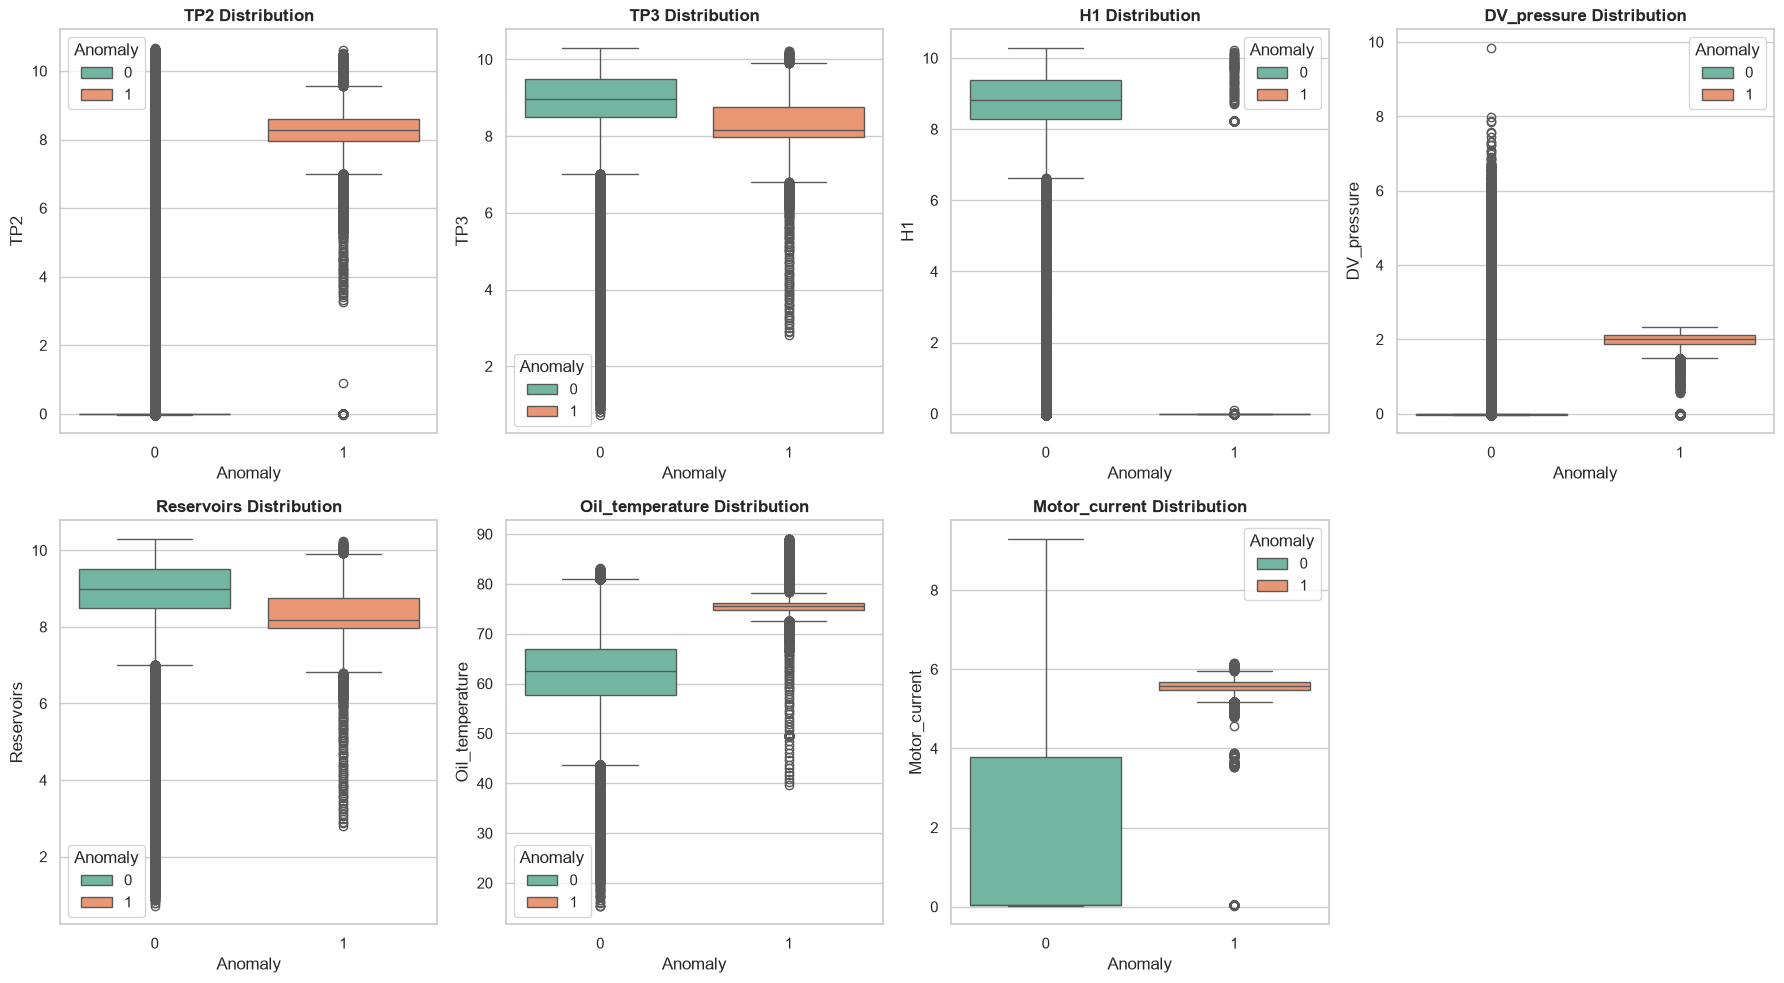

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()
for i, feature in enumerate(ANALOG_SENSORS):
    sns.boxplot(x='Anomaly', hue='Anomaly', y=feature, data=df, ax=axes[i],  palette='Set2')
    axes[i].set_title(f'{feature} Distribution', fontweight='bold')

fig.delaxes(axes[7])
plt.tight_layout()
plt.show()

## 6. Correlation Heatmap

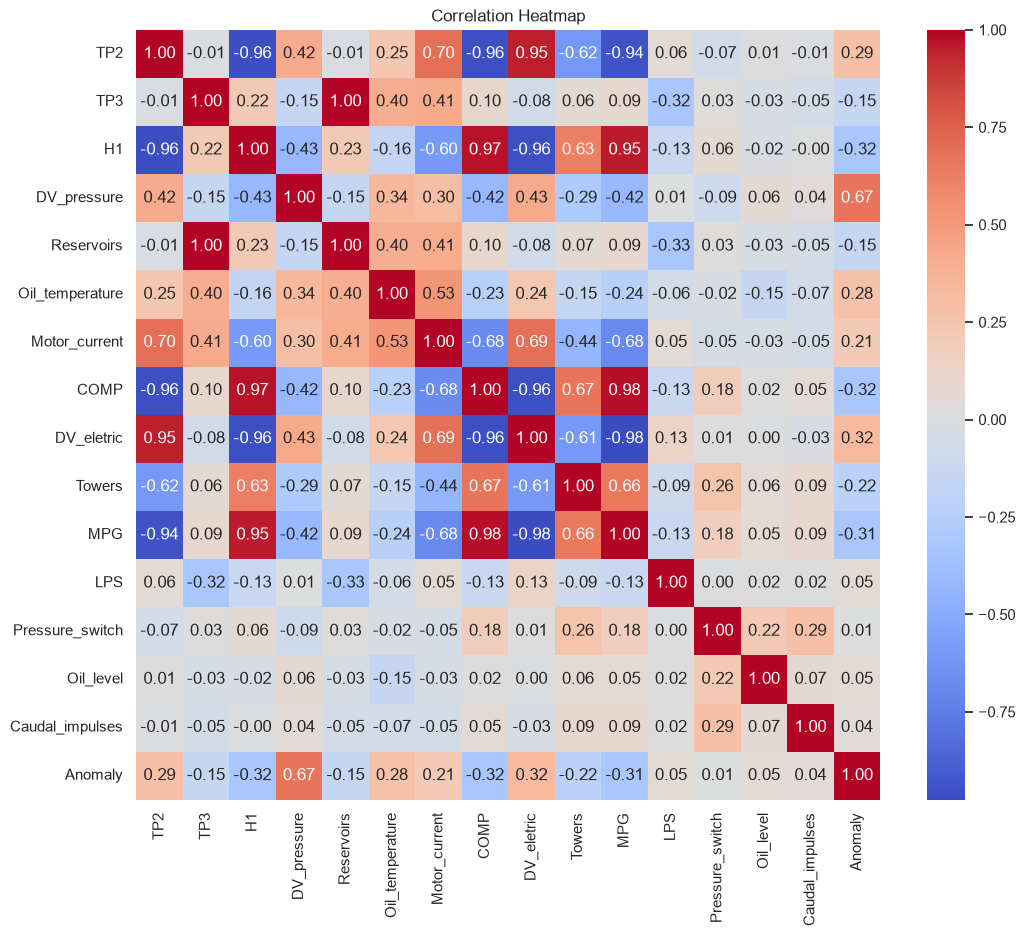

In [12]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## 7. Summary

| Dataset | MetroPT-3 Dataset |
|---|---|
| **Domain** | Urban railway transport (Air Production Unit) |
| **Task types** | Binary classification, anomaly detection, predictive maintenance |
| **Number of variables** | 15 process variables (7 analog, 8 digital) |
| **Number of classes** | 2 (1 normal + 1 undesirable event type: Air Leak) |
| **Number of instances** | 1 continuous multivariate time-series (1,516,948 observations) |
| **Sampling rate** | 10 seconds (downsampled from 1 Hz) |
| **Instance length** | 7 Months (February 1, 2020 to September 1, 2020) |
| **Label granularity** | Injected observation-level binary labels (derived from 4 external maintenance reports) |
| **Data quality issues** | Downtime gaps (17.5% missing time, no NaN values for monitored intervals), severe class imbalance |
| **Temporal structure** | 4 discrete continuous Air Leak events ranging from 4.5 hours to 52.5 hours |
| **Source diversity** | 100% Real (Collected from an on-board embedded device) |
| **Class imbalance** | 98.03% normal, 1.97% anomalous |

## 8. Domain Exploration
In order to perform transfer learning on the MetroPT-3 dataset, we need to define the source and target domains. We define three source-target domain pairs to examine how domain differences affect the transfer learning performance.

### Different Components (Towers)
We want to explore if the two air-drying towers present distinct data distributions.

Source (Tower 1): 121586 rows
Target (Tower 2): 1395362 rows


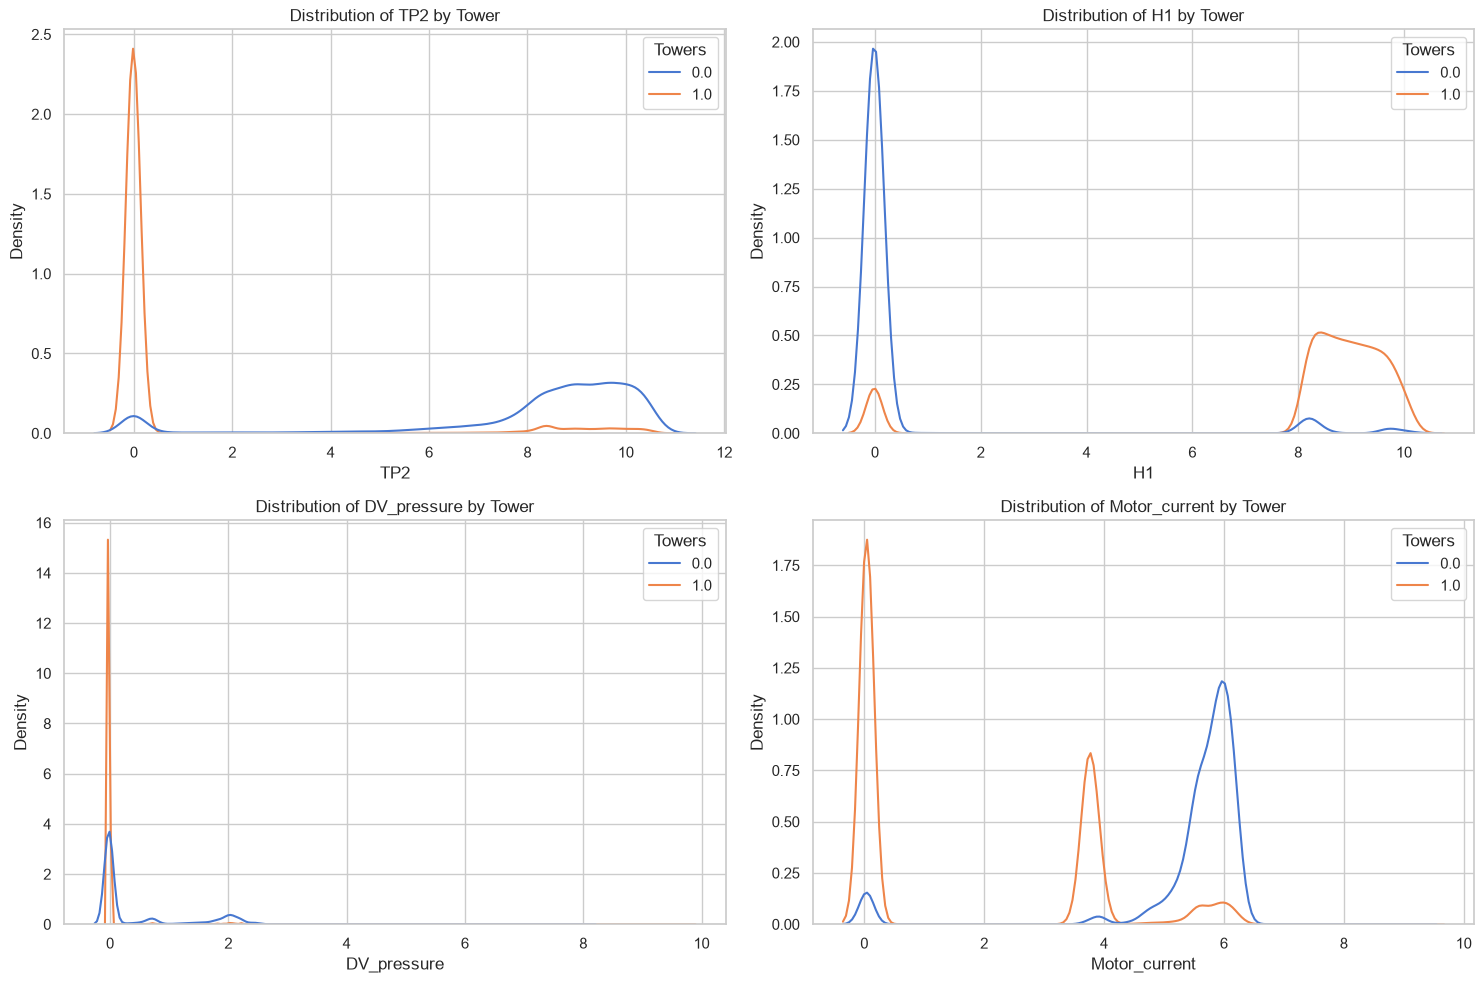

In [13]:
# Slice the dataset into source and target domains
source_towers = df[df['Towers'] == 0]
target_towers = df[df['Towers'] == 1]


print(f"Source (Tower 1): {len(source_towers)} rows")
print(f"Target (Tower 2): {len(target_towers)} rows")

# Features selected based on >20% absolute correlation and being analogue signals
features_to_plot = ['TP2', 'H1', 'DV_pressure', 'Motor_current']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    sns.kdeplot(data=df, x=feature, hue='Towers', ax=axes[i], common_norm=False)
    axes[i].set_title(f'Distribution of {feature} by Tower')

plt.tight_layout()
plt.show()


### Different Load Levels

The `Motor_current` feature acts as a proxy for the load level, it presents values close to 0A when it turns off, 4A when working offloaded, 7A when working under load, and 9A when it starts working.

Peaks at: [0.04 3.76 5.98] Amperes


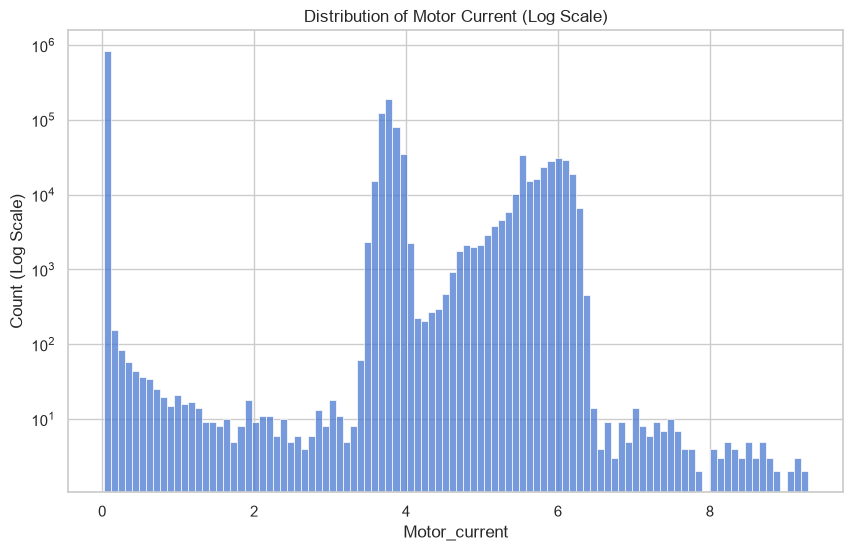

In [14]:
# find the exact peaks using KDE
# We use a small bandwidth to capture the sharp peaks accurately
kde = gaussian_kde(df['Motor_current'], bw_method=0.05)
x_range = np.linspace(df['Motor_current'].min(), df['Motor_current'].max(), 1000)
kde_values = kde(x_range)
peaks, _ = find_peaks(kde_values, height=0.01) # height filters out tiny noise

exact_peaks = x_range[peaks]
print(f"Peaks at: {np.round(exact_peaks, 2)} Amperes")

plt.figure(figsize=(10, 6))
# We use a log scale on the Y-axis to better visualize the distribution
sns.histplot(df['Motor_current'], bins=100, kde=False)
plt.yscale('log')
plt.title('Distribution of Motor Current (Log Scale)')
plt.ylabel('Count (Log Scale)')
plt.show()


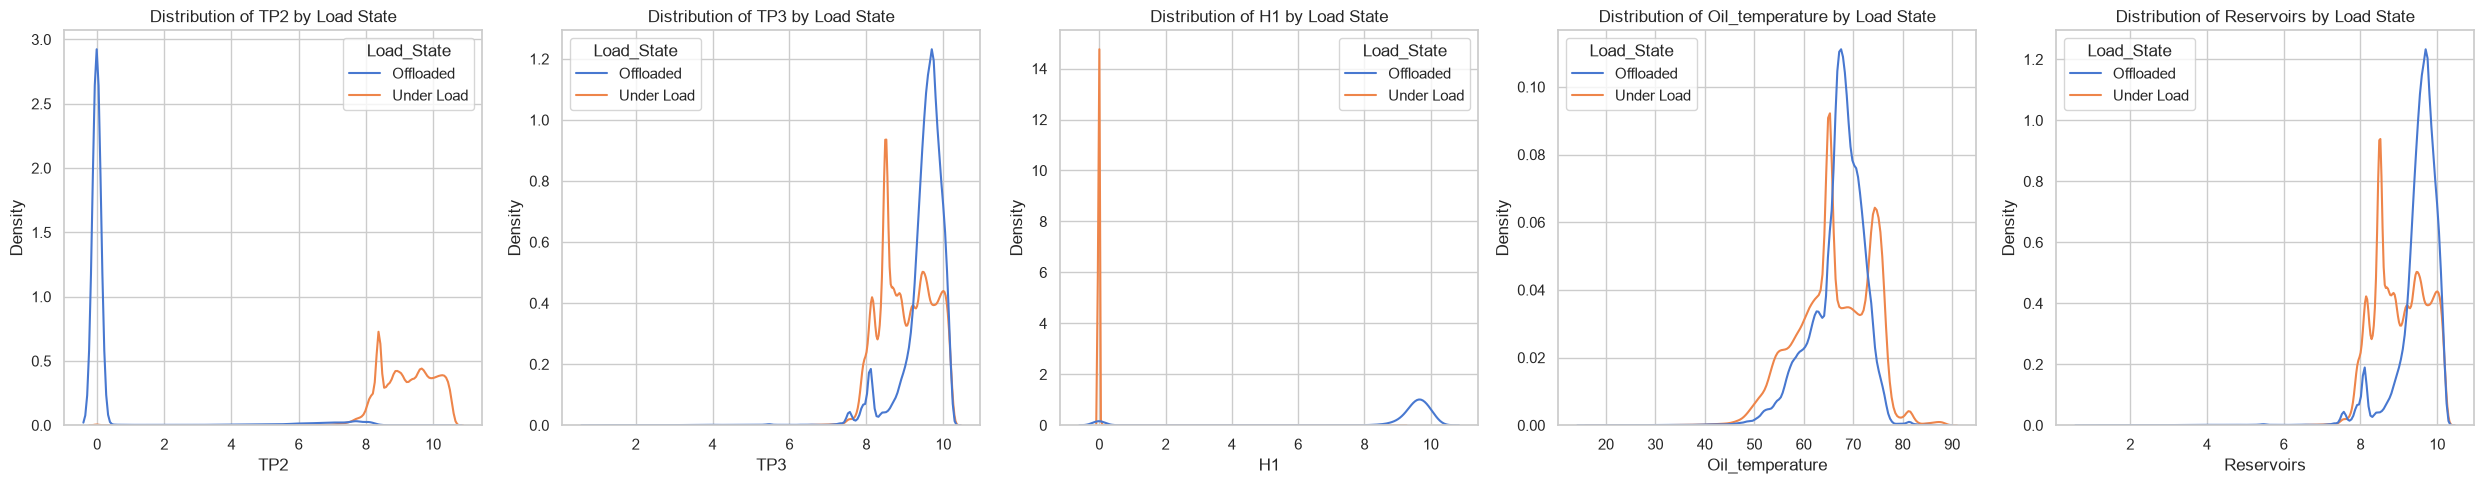

In [15]:
# Define load states based on the documentation AND data
def get_load_state(current):
    if current < 2:
        return 'Off'
    elif current < 5.5:
        return 'Offloaded'
    elif current < 8:
        return 'Under Load'
    else:
        return 'Starting'

df['Load_State'] = df['Motor_current'].apply(get_load_state)

source_load = df[df['Load_State'] == 'Offloaded']
target_load = df[df['Load_State'] == 'Under Load']

fig, axes = plt.subplots(1, 5, figsize=(25, 5))
features_for_load = ['TP2', 'TP3', 'H1', 'Oil_temperature', 'Reservoirs']

for i, feature in enumerate(features_for_load):
    sns.kdeplot(data=df[df['Load_State'].isin(['Offloaded', 'Under Load'])], 
                x=feature, hue='Load_State', ax=axes[i], common_norm=False)
    axes[i].set_title(f'Distribution of {feature} by Load State')

plt.tight_layout()
plt.show()


### Different Time Intervals

We look at environmental and temporal drift in the dataset by comparing operation during spring and summer months.

Source (Spring): 641982 rows
Target (Summer): 659586 rows


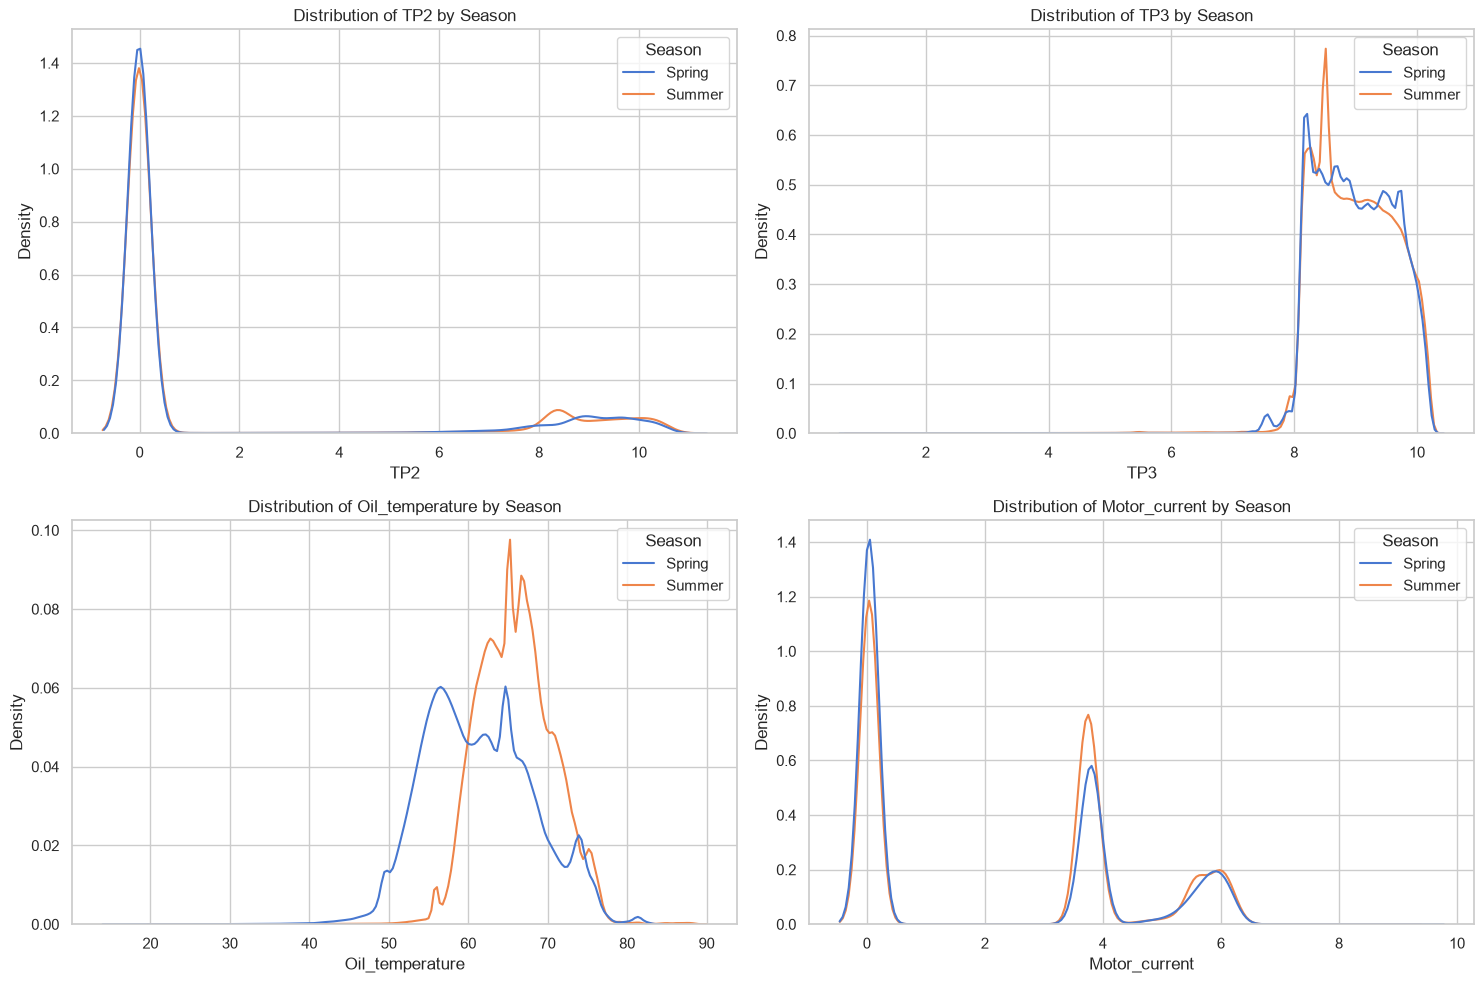

In [16]:
# Create a 'Month' column if it doesn't already exist from the timestamp
# df['timestamp'] = pd.to_datetime(df['timestamp']) # Uncomment if not already datetime
df['Month'] = df.index.month
# Define our domains: Spring (March, April, May) and Summer (June, July, August)
# Create a new categorical column for plotting
def assign_season(month):
    if month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Other'
df['Season'] = df['Month'].apply(assign_season)

source_time = df[df['Season'] == 'Spring']
target_time = df[df['Season'] == 'Summer']

print(f"Source (Spring): {len(source_time)} rows")
print(f"Target (Summer): {len(target_time)} rows")

# Filter out 'Other' so we only plot our two specific domains
season_df = df[df['Season'] != 'Other']
# Select thermodynamic features most likely to be affected by seasons
thermo_features = ['TP2', 'TP3', 'Oil_temperature', 'Motor_current']
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()
for i, feature in enumerate(thermo_features):
    sns.kdeplot(data=season_df, x=feature, hue='Season', ax=axes[i], common_norm=False)
    axes[i].set_title(f'Distribution of {feature} by Season')
plt.tight_layout()
plt.show()


=== Exploring Conditional Shift (Anomalies Only) ===


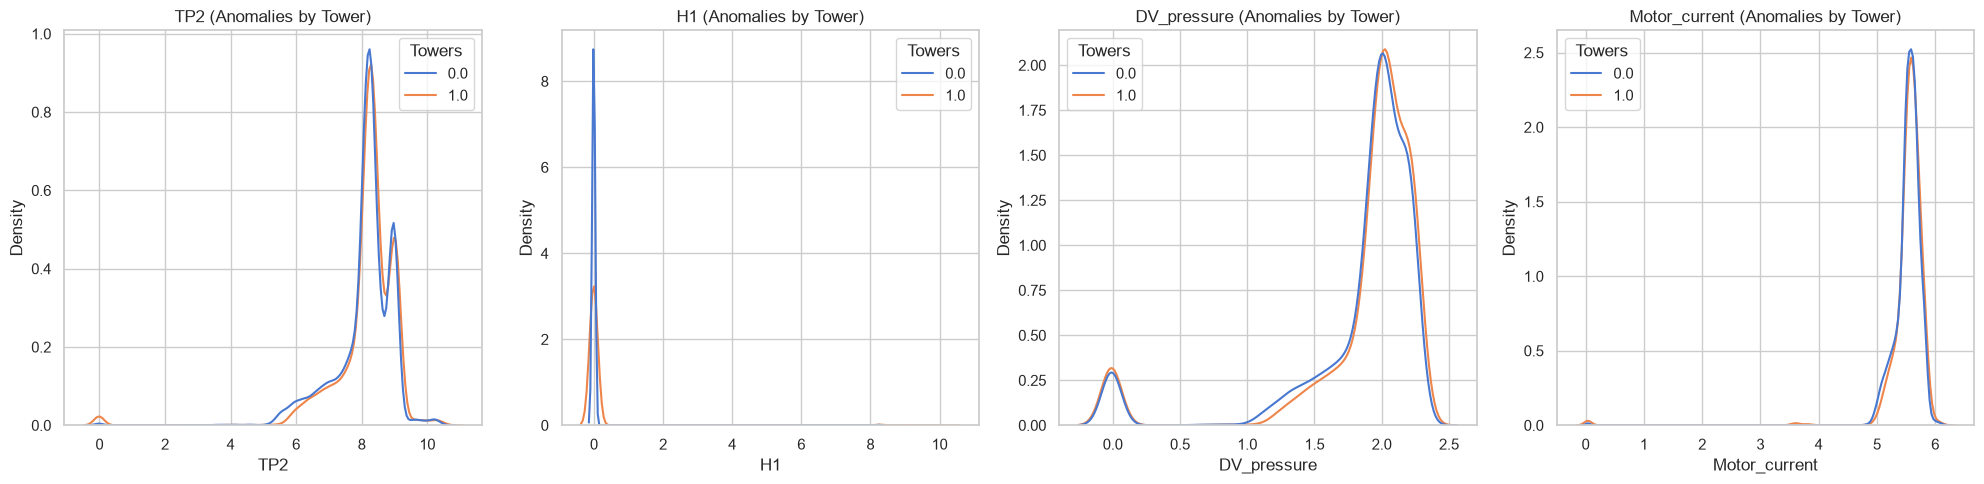

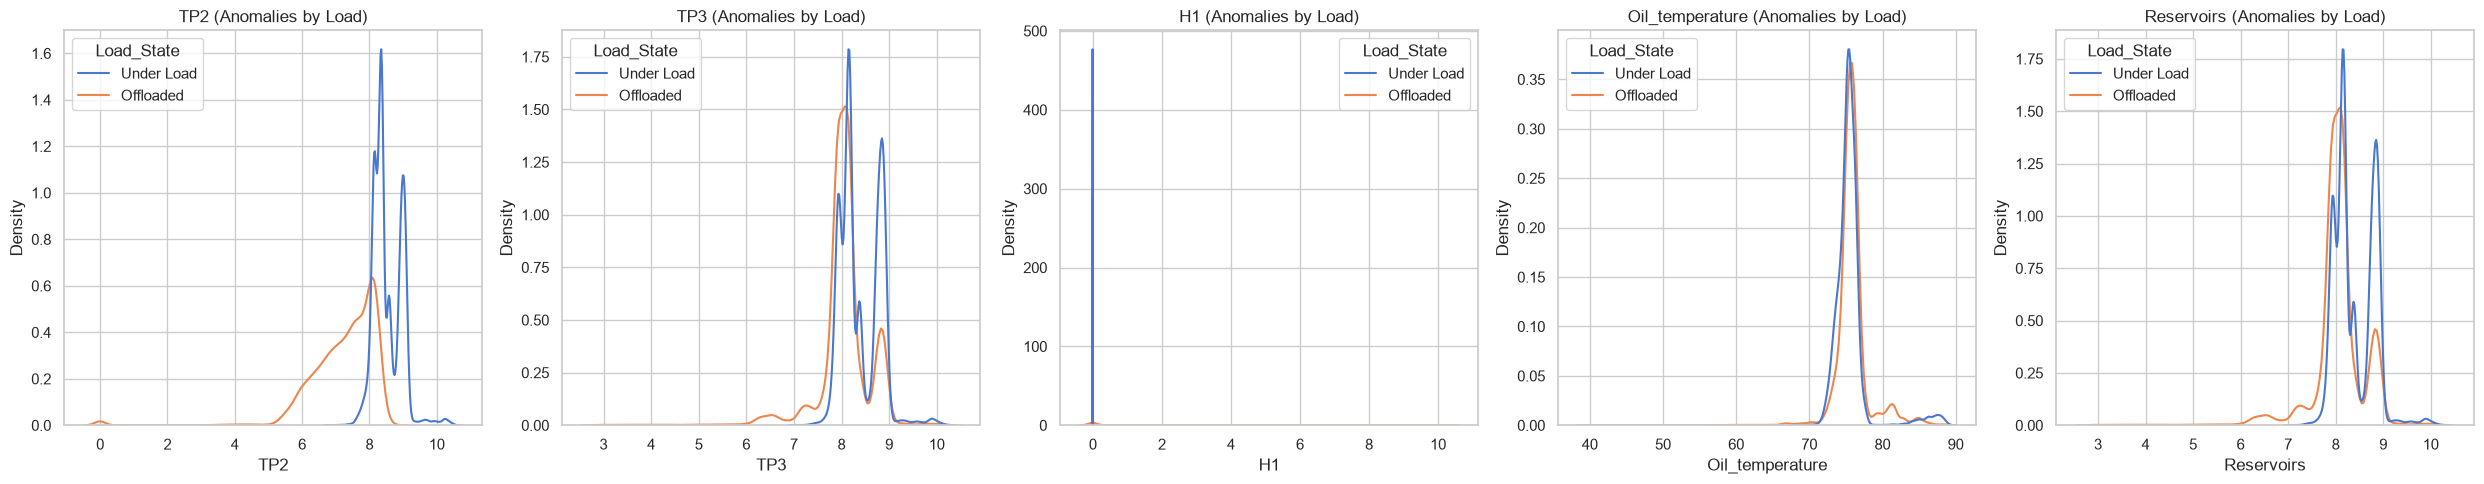

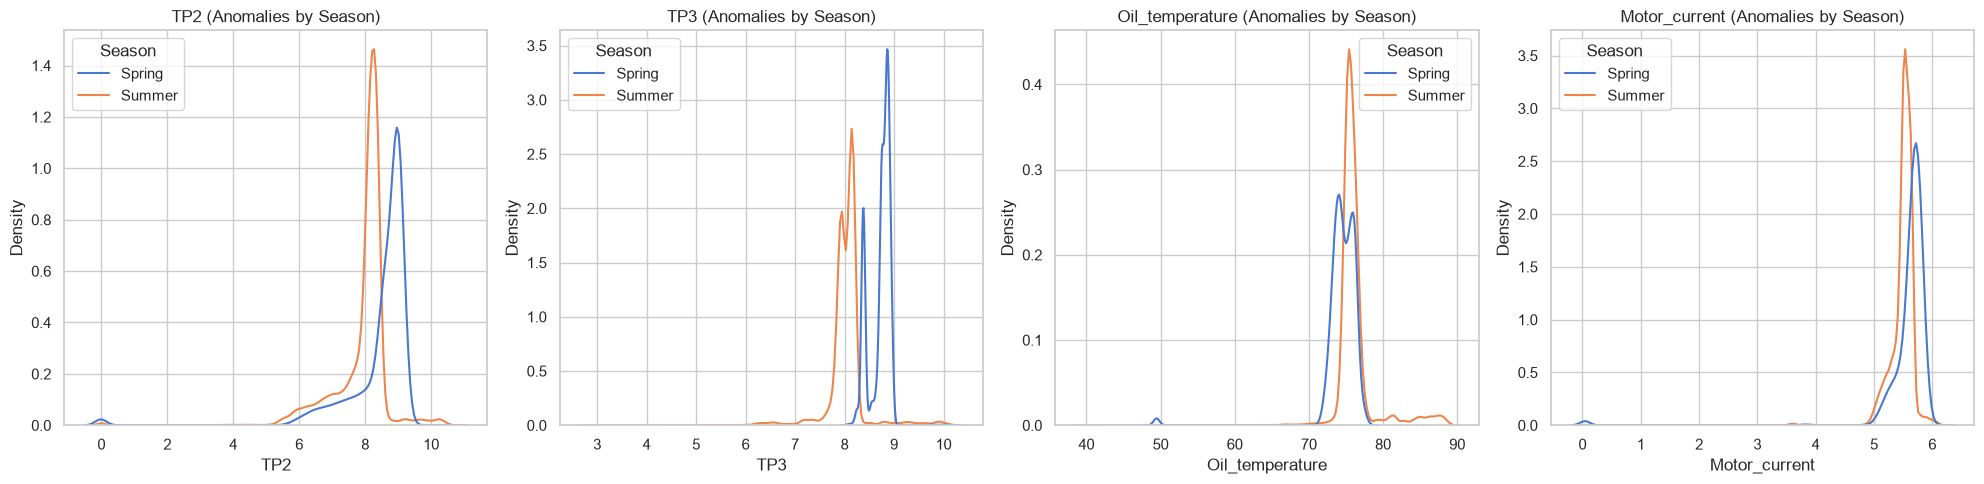

In [17]:
# =====================================================================
# Target Variable (Anomaly) Exploration: The Search for Concept Drift
# =====================================================================
print("=== Exploring Conditional Shift (Anomalies Only) ===")
# Filter the dataset to only look at the physical behavior of Anomalies
anomalies_df = df[df['Anomaly'] == 1]

# 1. Towers Anomaly Shift
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, feature in enumerate(features_to_plot):
    sns.kdeplot(data=anomalies_df, x=feature, hue='Towers', ax=axes[i], common_norm=False)
    axes[i].set_title(f'{feature} (Anomalies by Tower)')
plt.tight_layout()
plt.show()

# 2. Load Levels Anomaly Shift
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
for i, feature in enumerate(features_for_load):
    sns.kdeplot(data=anomalies_df[anomalies_df['Load_State'].isin(['Offloaded', 'Under Load'])], 
                x=feature, hue='Load_State', ax=axes[i], common_norm=False)
    axes[i].set_title(f'{feature} (Anomalies by Load)')
plt.tight_layout()
plt.show()

# 3. Seasons Anomaly Shift
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, feature in enumerate(thermo_features):
    sns.kdeplot(data=anomalies_df[anomalies_df['Season'] != 'Other'], 
                x=feature, hue='Season', ax=axes[i], common_norm=False)
    axes[i].set_title(f'{feature} (Anomalies by Season)')
plt.tight_layout()
plt.show()